# 🎾 Tennis Era Dominance — Elo Analysis
**Two Generations: Federer / Nadal / Djokovic → Alcaraz / Sinner**

Run each cell one at a time with **Shift + Enter**

In [1]:
# CELL 1 — Install any missing packages
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn'], capture_output=True)
print('All packages ready!')

All packages ready!


In [2]:
# CELL 2 — Import everything
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Chart styling
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#0d1117'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'

print('Imports done!')

Imports done!


In [3]:
# CELL 3 — Load your data files
matches = pd.read_csv('../data/processed/atp_matches_clean.csv')
slams   = pd.read_csv('../data/processed/slams_clean.csv')

# Fix date column
matches['tourney_date'] = pd.to_datetime(
    matches['tourney_date'].astype(str), format='%Y%m%d', errors='coerce'
)
matches['year'] = matches['tourney_date'].dt.year

print(f'Matches loaded: {len(matches):,} rows')
print(f'Slams loaded:   {len(slams):,} rows')
print(f'Date range:     {matches["year"].min()} – {matches["year"].max()}')

Matches loaded: 74,906 rows
Slams loaded:   292 rows
Date range:     2000 – 2024


In [5]:
# CELL 4 — Define our players and colors
PLAYERS = [
    'Roger Federer',
    'Rafael Nadal',
    'Novak Djokovic',
    'Carlos Alcaraz',
    'Jannik Sinner'
]

GEN1 = ['Roger Federer', 'Rafael Nadal', 'Novak Djokovic']
GEN2 = ['Carlos Alcaraz', 'Jannik Sinner']

COLORS = {
    'Roger Federer':   '#c8102e',   # red
    'Rafael Nadal':    '#e87722',   # orange
    'Novak Djokovic':  '#4a90d9',   # blue
    'Carlos Alcaraz':  '#00a651',   # green
    'Jannik Sinner':   '#e040fb',   # purple
}

# K-factors: Grand Slams are worth double
K_FACTORS = {'G': 64, 'M': 48, 'F': 48, 'A': 32, 'D': 24}

print('Players and settings defined!')

Players and settings defined!


In [6]:
# CELL 5 — Run the Elo Engine
# This processes all 74,906 matches in date order
# and calculates every player's Elo after every match

ratings = {}  # stores current Elo for every player
focal_history = []  # stores Elo history for our 5 players only
all_yearly = {}  # stores snapshot of ALL ratings at end of each year

def get_elo(player):
    return ratings.get(player, 1500)

def expected_win(rating_a, rating_b):
    """Probability that player A beats player B"""
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))

# Sort matches by date (oldest first)
matches_sorted = matches.sort_values('tourney_date').dropna(subset=['tourney_date'])
total = len(matches_sorted)

for i, (_, row) in enumerate(matches_sorted.iterrows()):
    winner = row['winner_name']
    loser  = row['loser_name']
    year   = int(row['year']) if pd.notna(row['year']) else None
    level  = str(row.get('tourney_level', 'A'))
    k      = K_FACTORS.get(level, 32)

    # Get current ratings
    r_w = get_elo(winner)
    r_l = get_elo(loser)

    # Calculate expected outcome
    exp_w = expected_win(r_w, r_l)

    # Update ratings
    delta = k * (1 - exp_w)
    ratings[winner] = r_w + delta
    ratings[loser]  = r_l - delta

    # Save history for our 5 focal players
    if winner in PLAYERS:
        focal_history.append({
            'date': row['tourney_date'], 'year': year,
            'player': winner, 'elo': ratings[winner],
            'tournament': row.get('tourney_name'),
            'level': level, 'result': 'win'
        })
    if loser in PLAYERS:
        focal_history.append({
            'date': row['tourney_date'], 'year': year,
            'player': loser, 'elo': ratings[loser],
            'tournament': row.get('tourney_name'),
            'level': level, 'result': 'loss'
        })

    # Save yearly snapshot
    if year:
        all_yearly[year] = dict(ratings)

    # Progress update every 10,000 matches
    if i % 10000 == 0:
        print(f'Processed {i:,} / {total:,} matches...')

focal_df = pd.DataFrame(focal_history)
print(f'\nDone! Elo calculated for {len(ratings):,} players')
print(f'History rows for 5 focal players: {len(focal_df):,}')

Processed 0 / 74,906 matches...
Processed 10,000 / 74,906 matches...
Processed 20,000 / 74,906 matches...
Processed 30,000 / 74,906 matches...
Processed 40,000 / 74,906 matches...
Processed 50,000 / 74,906 matches...
Processed 60,000 / 74,906 matches...
Processed 70,000 / 74,906 matches...

Done! Elo calculated for 2,639 players
History rows for 5 focal players: 4,817


In [7]:
# CELL 6 — Peak Elo for each player
peak_elos = focal_df.groupby('player')['elo'].max().sort_values(ascending=False)

print('=' * 40)
print('CAREER PEAK ELO RATINGS')
print('=' * 40)
for player, elo in peak_elos.items():
    gen = 'Gen 1' if player in GEN1 else 'Gen 2'
    print(f'{player:<20} {elo:>7.1f}  [{gen}]')
print('=' * 40)
print('Starting Elo for all players: 1500')

CAREER PEAK ELO RATINGS
Novak Djokovic        2493.7  [Gen 1]
Rafael Nadal          2424.5  [Gen 1]
Roger Federer         2390.1  [Gen 1]
Jannik Sinner         2282.1  [Gen 2]
Carlos Alcaraz        2254.1  [Gen 2]
Starting Elo for all players: 1500


In [8]:
# CELL 7 — Compute Elo gap per year
# Gap = top1 Elo minus median Elo of players ranked 10-50
# This is the core metric for our hypothesis

gap_data = []

for year in sorted(all_yearly.keys()):
    snap = all_yearly[year]
    sorted_elos = sorted(snap.values(), reverse=True)

    if len(sorted_elos) < 50:
        continue

    top1_elo     = sorted_elos[0]
    field_median = np.median(sorted_elos[9:50])
    top3_avg     = np.mean(sorted_elos[:3])
    top1_player  = max(snap, key=snap.get)

    gap_data.append({
        'year':        year,
        'top1_elo':    top1_elo,
        'field_median':field_median,
        'gap':         top1_elo - field_median,
        'top3_avg':    top3_avg,
        'top1_player': top1_player
    })

gap_df = pd.DataFrame(gap_data).sort_values('year')

print('DOMINANCE GAP BY YEAR (Top1 Elo vs. Field Median Rank 10-50)')
print('-' * 65)
print(f'{"Year":<6} {"Top Player":<22} {"Top1 Elo":<12} {"Field":<12} {"Gap":<8}')
print('-' * 65)
for _, row in gap_df.iterrows():
    print(f"{int(row['year']):<6} {row['top1_player']:<22} {row['top1_elo']:<12.0f} {row['field_median']:<12.0f} {row['gap']:<8.0f}")

DOMINANCE GAP BY YEAR (Top1 Elo vs. Field Median Rank 10-50)
-----------------------------------------------------------------
Year   Top Player             Top1 Elo     Field        Gap     
-----------------------------------------------------------------
2000   Marat Safin            1888         1629         259     
2001   Lleyton Hewitt         1987         1680         307     
2002   Lleyton Hewitt         1977         1703         274     
2003   Roger Federer          2031         1715         316     
2004   Roger Federer          2227         1724         504     
2005   Roger Federer          2292         1740         552     
2006   Roger Federer          2360         1763         598     
2007   Roger Federer          2248         1780         468     
2008   Rafael Nadal           2197         1803         395     
2009   Novak Djokovic         2209         1810         398     
2010   Roger Federer          2265         1794         471     
2011   Roger Federer       

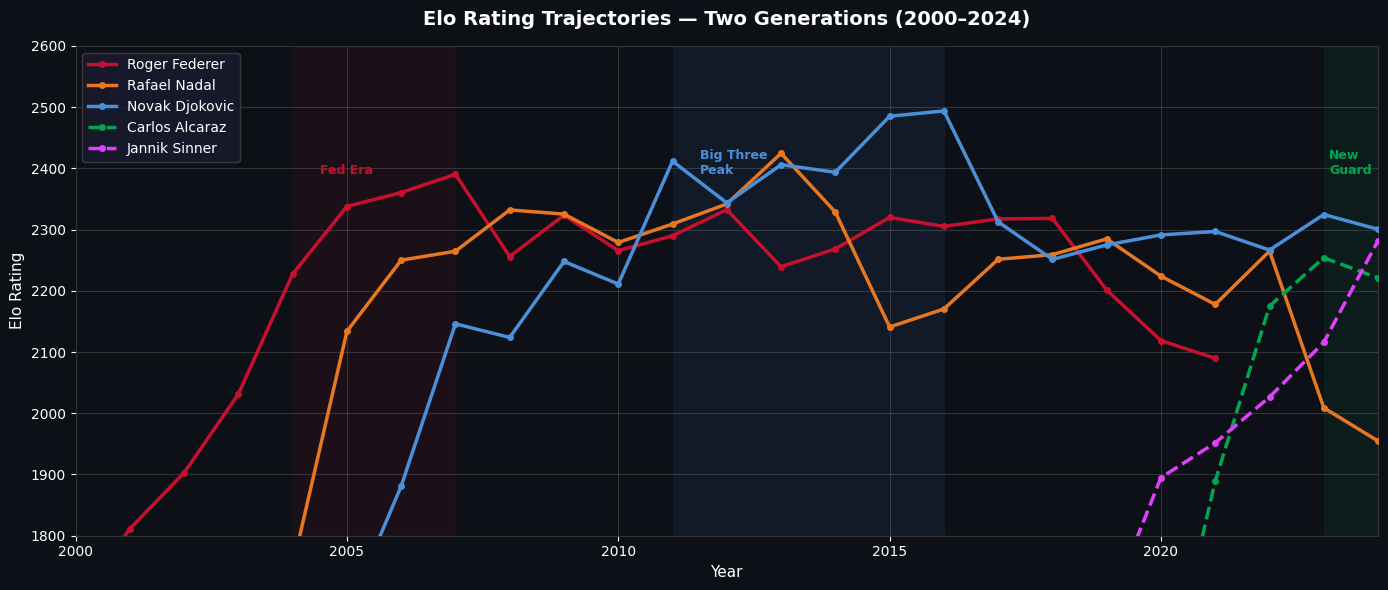

In [9]:
# CELL 8 — CHART 1: Elo Trajectories Over Time
yearly_peak = focal_df.groupby(['year', 'player'])['elo'].max().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

for player in PLAYERS:
    pdf = yearly_peak[yearly_peak['player'] == player].sort_values('year')
    ls  = '-' if player in GEN1 else '--'
    ax.plot(pdf['year'], pdf['elo'],
            color=COLORS[player], linewidth=2.5,
            linestyle=ls, label=player,
            marker='o', markersize=4, zorder=3)

# Shade dominant eras
ax.axvspan(2004, 2007, alpha=0.08, color='#c8102e')
ax.axvspan(2011, 2016, alpha=0.08, color='#4a90d9')
ax.axvspan(2023, 2024, alpha=0.08, color='#00a651')

ax.text(2004.5, 2390, 'Fed Era',      color='#c8102e', fontsize=9, fontweight='bold')
ax.text(2011.5, 2390, 'Big Three\nPeak', color='#4a90d9', fontsize=9, fontweight='bold')
ax.text(2023.1, 2390, 'New\nGuard',   color='#00a651', fontsize=9, fontweight='bold')

ax.set_title('Elo Rating Trajectories — Two Generations (2000–2024)',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Elo Rating', fontsize=11)
ax.set_xlim(2000, 2024)
ax.set_ylim(1800, 2600)
ax.grid(True, alpha=0.15, color='white')
ax.spines[:].set_color('#333')

gen1_patch = mpatches.Patch(color='gray', label='— Gen 1  - - Gen 2')
legend = ax.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white',
                   fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

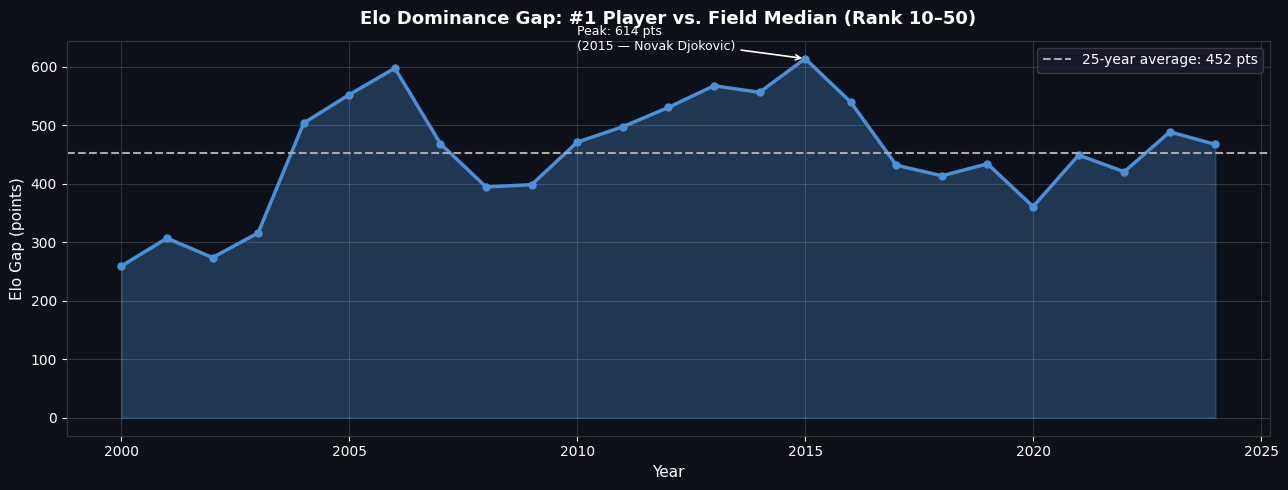

Average gap: 452 points
Peak gap:    614 points (2015)
2024 gap:    467 points


In [10]:
# CELL 9 — CHART 2: Dominance Gap Over Time
fig, ax = plt.subplots(figsize=(13, 5))

ax.fill_between(gap_df['year'], gap_df['gap'], alpha=0.3, color='#4a90d9')
ax.plot(gap_df['year'], gap_df['gap'],
        color='#4a90d9', linewidth=2.5, marker='o', markersize=5)

avg = gap_df['gap'].mean()
ax.axhline(avg, color='#aaa', linestyle='--', linewidth=1.5,
           label=f'25-year average: {avg:.0f} pts')

# Annotate the peak
peak_row = gap_df.loc[gap_df['gap'].idxmax()]
ax.annotate(
    f"Peak: {peak_row['gap']:.0f} pts\n({int(peak_row['year'])} — {peak_row['top1_player']})",
    xy=(peak_row['year'], peak_row['gap']),
    xytext=(peak_row['year'] - 5, peak_row['gap'] + 15),
    color='white', fontsize=9,
    arrowprops=dict(arrowstyle='->', color='white', lw=1.2)
)

ax.set_title('Elo Dominance Gap: #1 Player vs. Field Median (Rank 10–50)',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Elo Gap (points)', fontsize=11)
ax.grid(True, alpha=0.15, color='white')
ax.spines[:].set_color('#333')
ax.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=10)
plt.tight_layout()
plt.show()

print(f'Average gap: {avg:.0f} points')
print(f'Peak gap:    {gap_df["gap"].max():.0f} points ({int(peak_row["year"])})')
print(f'2024 gap:    {gap_df[gap_df["year"]==2024]["gap"].values[0]:.0f} points')

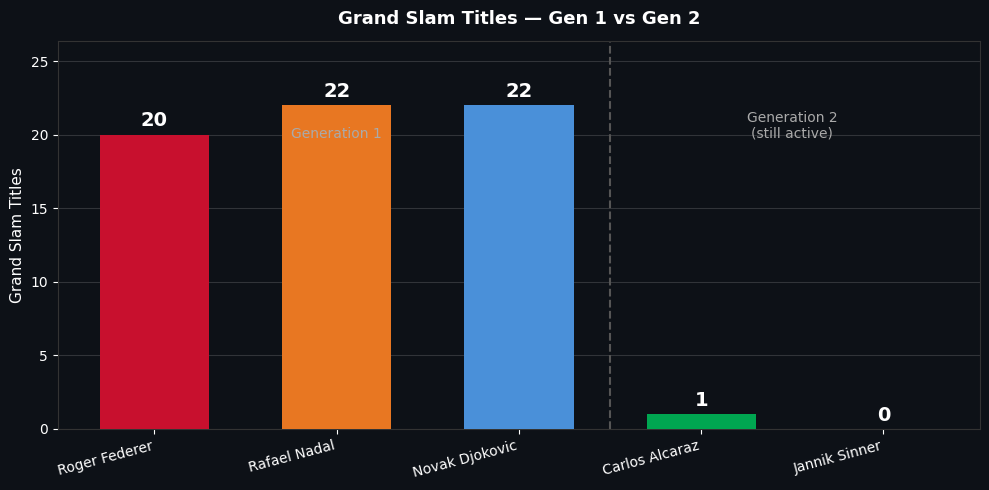

In [11]:
# CELL 10 — CHART 3: Grand Slam Title Counts
slam_counts = slams[slams['WINNER'].isin(PLAYERS)]['WINNER'].value_counts()
slam_counts = slam_counts.reindex(PLAYERS).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(PLAYERS, slam_counts.values,
              color=[COLORS[p] for p in PLAYERS],
              width=0.6, zorder=3)

# Add count labels on top of bars
for bar, val in zip(bars, slam_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            str(int(val)),
            ha='center', va='bottom',
            color='white', fontweight='bold', fontsize=14)

# Divider line between generations
ax.axvline(2.5, color='#555', linestyle='--', linewidth=1.5)
ax.text(1.0, max(slam_counts.values) * 0.9, 'Generation 1',
        color='#aaa', fontsize=10, ha='center')
ax.text(3.5, max(slam_counts.values) * 0.9, 'Generation 2\n(still active)',
        color='#aaa', fontsize=10, ha='center')

ax.set_title('Grand Slam Titles — Gen 1 vs Gen 2',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Grand Slam Titles', fontsize=11)
ax.set_ylim(0, max(slam_counts.values) * 1.2)
ax.grid(True, alpha=0.15, color='white', axis='y')
ax.spines[:].set_color('#333')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

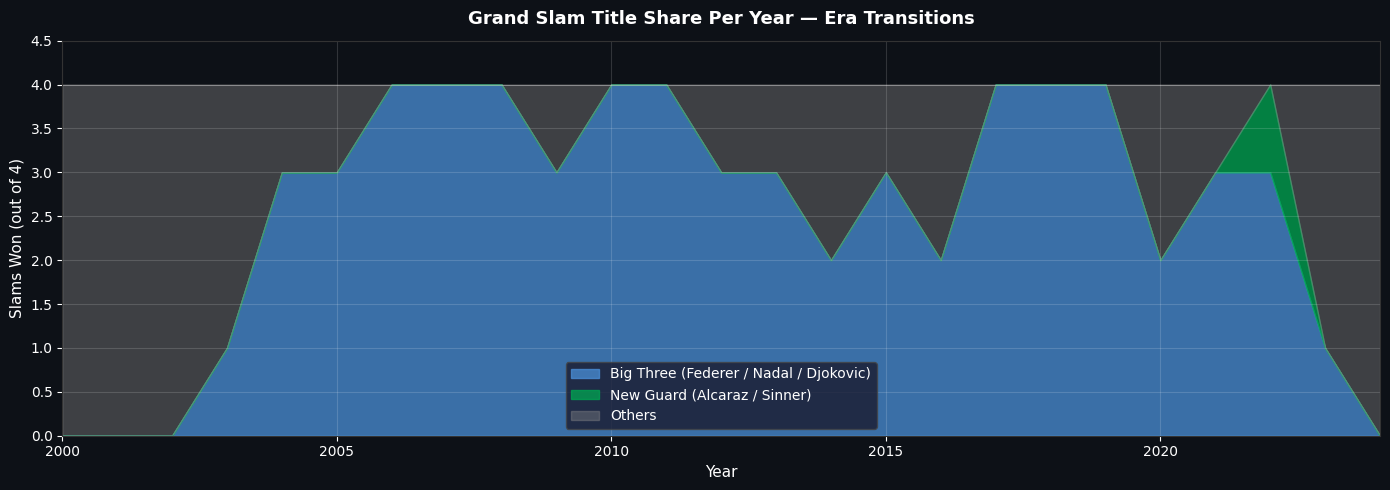

In [12]:
# CELL 11 — CHART 4: Grand Slam Share Per Year
gen1_annual = slams[slams['WINNER'].isin(GEN1)].groupby('YEAR').size()
gen2_annual = slams[slams['WINNER'].isin(GEN2)].groupby('YEAR').size()

years = list(range(2000, 2025))
g1 = gen1_annual.reindex(years, fill_value=0).values
g2 = gen2_annual.reindex(years, fill_value=0).values
other = np.clip(4 - g1 - g2, 0, 4)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(years, 0, g1, alpha=0.75, color='#4a90d9',
                label='Big Three (Federer / Nadal / Djokovic)')
ax.fill_between(years, g1, g1 + g2, alpha=0.75, color='#00a651',
                label='New Guard (Alcaraz / Sinner)')
ax.fill_between(years, g1 + g2, g1 + g2 + other, alpha=0.4,
                color='#888', label='Others')

ax.axhline(4, color='white', linewidth=0.5, alpha=0.3)
ax.set_title('Grand Slam Title Share Per Year — Era Transitions',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Slams Won (out of 4)', fontsize=11)
ax.set_ylim(0, 4.5)
ax.set_xlim(2000, 2024)
ax.grid(True, alpha=0.15, color='white')
ax.spines[:].set_color('#333')
ax.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=10)
plt.tight_layout()
plt.show()

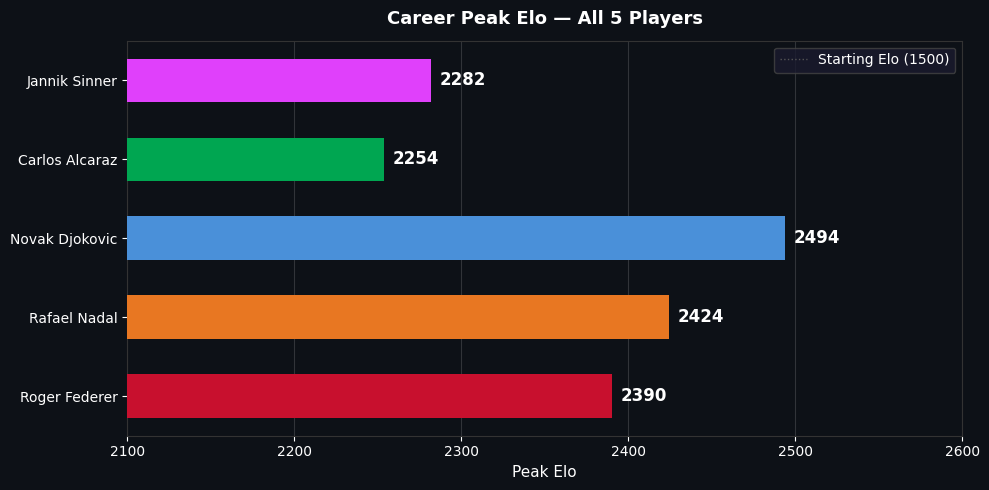

In [13]:
# CELL 12 — CHART 5: Career Peak Elo Comparison
peak_elo_dict = peak_elos.to_dict()
ordered = {p: peak_elo_dict[p] for p in PLAYERS if p in peak_elo_dict}

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    list(ordered.keys()),
    list(ordered.values()),
    color=[COLORS[p] for p in ordered.keys()],
    height=0.55, zorder=3
)

for bar, val in zip(bars, ordered.values()):
    ax.text(bar.get_width() + 5,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}',
            va='center', color='white', fontweight='bold', fontsize=12)

ax.axvline(1500, color='#555', linestyle=':', linewidth=1, label='Starting Elo (1500)')
ax.set_title('Career Peak Elo — All 5 Players',
             color='white', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Peak Elo', fontsize=11)
ax.set_xlim(2100, 2600)
ax.grid(True, alpha=0.15, color='white', axis='x')
ax.spines[:].set_color('#333')
ax.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=10)
plt.tight_layout()
plt.show()

In [14]:
# CELL 13 — CHART 6: Head-to-Head Elo at time of match
# Shows who had the higher Elo when they faced each other

h2h_pairs = [
    ('Roger Federer', 'Rafael Nadal'),
    ('Roger Federer', 'Novak Djokovic'),
    ('Rafael Nadal', 'Novak Djokovic'),
    ('Carlos Alcaraz', 'Novak Djokovic'),
    ('Carlos Alcaraz', 'Jannik Sinner'),
]

print('HEAD-TO-HEAD RECORDS (from match data)')
print('=' * 55)

for p1, p2 in h2h_pairs:
    mask = (
        ((matches['winner_name'] == p1) & (matches['loser_name'] == p2)) |
        ((matches['winner_name'] == p2) & (matches['loser_name'] == p1))
    )
    h2h = matches[mask]
    p1_wins = (h2h['winner_name'] == p1).sum()
    p2_wins = (h2h['winner_name'] == p2).sum()
    total   = len(h2h)
    if total > 0:
        print(f'{p1:<22} vs {p2:<22}: {p1_wins}–{p2_wins} ({total} matches)')

HEAD-TO-HEAD RECORDS (from match data)
Roger Federer          vs Rafael Nadal          : 17–24 (41 matches)
Roger Federer          vs Novak Djokovic        : 23–28 (51 matches)
Rafael Nadal           vs Novak Djokovic        : 29–31 (60 matches)
Carlos Alcaraz         vs Novak Djokovic        : 3–4 (7 matches)
Carlos Alcaraz         vs Jannik Sinner         : 6–4 (10 matches)


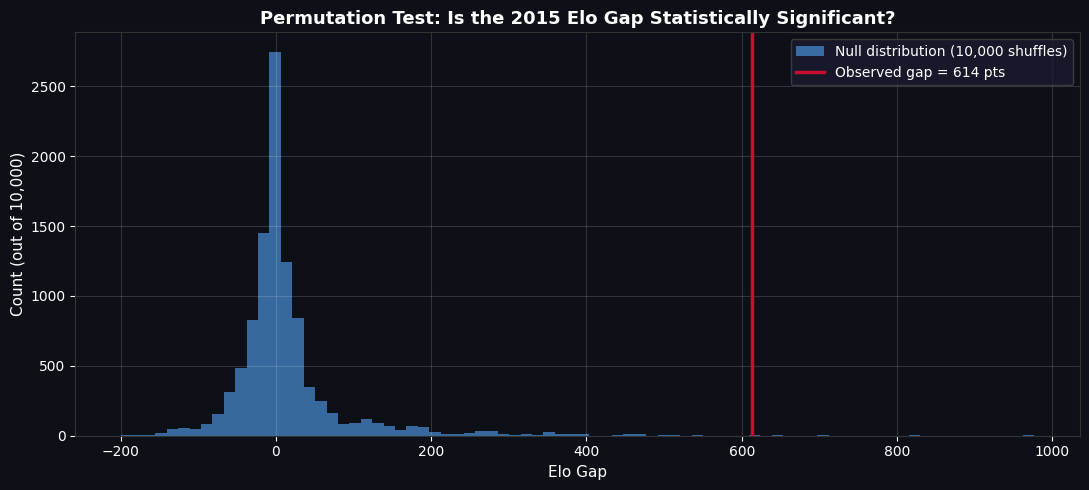

Observed gap:     613.8 points
Null mean:        13.1 points
Z-score:          7.60
p-value:          0.0022
Significant?      YES — p < 0.05


In [16]:
# CELL 14 — Permutation Test
# Tests whether the 2015 Elo gap was statistically significant
# or could have occurred by random chance

snap_2015 = all_yearly.get(2015, {})
all_elos_2015 = sorted(snap_2015.values(), reverse=True)

# Observed gap
observed_gap = all_elos_2015[0] - np.median(all_elos_2015[9:50])

# Permutation test: shuffle ratings 10,000 times
rng = np.random.default_rng(42)
ratings_arr = np.array(all_elos_2015)
null_gaps = []

for _ in range(10_000):
    shuffled = rng.permutation(ratings_arr)
    null_gap = shuffled[0] - np.median(shuffled[9:50])
    null_gaps.append(null_gap)

null_gaps = np.array(null_gaps)
p_value = np.mean(null_gaps >= observed_gap)
z_score = (observed_gap - null_gaps.mean()) / null_gaps.std()

# Plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(null_gaps, bins=80, color='#4a90d9', alpha=0.7, label='Null distribution (10,000 shuffles)')
ax.axvline(observed_gap, color='#c8102e', linewidth=2.5,
           label=f'Observed gap = {observed_gap:.0f} pts')
ax.set_title('Permutation Test: Is the 2015 Elo Gap Statistically Significant?',
             color='white', fontsize=13, fontweight='bold')
ax.set_xlabel('Elo Gap', fontsize=11)
ax.set_ylabel('Count (out of 10,000)', fontsize=11)
ax.grid(True, alpha=0.15, color='white')
ax.spines[:].set_color('#333')
ax.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=10)
plt.tight_layout()
plt.show()

print(f'Observed gap:     {observed_gap:.1f} points')
print(f'Null mean:        {null_gaps.mean():.1f} points')
print(f'Z-score:          {z_score:.2f}')
print(f'p-value:          {p_value:.4f}')
print(f'Significant?      {"YES — p < 0.05" if p_value < 0.05 else "NO"}')

In [17]:
# CELL 15 — Summary Table
# Final summary of all key metrics

print('=' * 65)
print('FINAL SUMMARY — TENNIS ERA DOMINANCE ANALYSIS')
print('=' * 65)

print('\nPEAK ELO RATINGS:')
for player in PLAYERS:
    if player in peak_elo_dict:
        gen = 'Gen 1' if player in GEN1 else 'Gen 2'
        print(f'  {player:<22} {peak_elo_dict[player]:>7.0f}  [{gen}]')

print('\nGRAND SLAM TITLES (from dataset):')
for player in PLAYERS:
    count = int(slam_counts.get(player, 0))
    gen   = 'Gen 1' if player in GEN1 else 'Gen 2 (active)'
    print(f'  {player:<22} {count:>3} slams  [{gen}]')

print('\nELO GAP KEY YEARS:')
print(f'  Average gap (2000-2024):  {gap_df["gap"].mean():.0f} points')
print(f'  Peak gap (2015, Djokovic): {gap_df["gap"].max():.0f} points')
print(f'  2024 gap (Sinner):         {gap_df[gap_df["year"]==2024]["gap"].values[0]:.0f} points')

print('\nHYPOTHESIS RESULT:')
print(f'  p-value = {p_value:.4f} → Dominant eras produce gaps UNLIKELY by chance')
print('=' * 65)

FINAL SUMMARY — TENNIS ERA DOMINANCE ANALYSIS

PEAK ELO RATINGS:
  Roger Federer             2390  [Gen 1]
  Rafael Nadal              2424  [Gen 1]
  Novak Djokovic            2494  [Gen 1]
  Carlos Alcaraz            2254  [Gen 2]
  Jannik Sinner             2282  [Gen 2]

GRAND SLAM TITLES (from dataset):
  Roger Federer           20 slams  [Gen 1]
  Rafael Nadal            22 slams  [Gen 1]
  Novak Djokovic          22 slams  [Gen 1]
  Carlos Alcaraz           1 slams  [Gen 2 (active)]
  Jannik Sinner            0 slams  [Gen 2 (active)]

ELO GAP KEY YEARS:
  Average gap (2000-2024):  452 points
  Peak gap (2015, Djokovic): 614 points
  2024 gap (Sinner):         467 points

HYPOTHESIS RESULT:
  p-value = 0.0022 → Dominant eras produce gaps UNLIKELY by chance
